<a href="https://colab.research.google.com/github/shruti-2562/FML/blob/main/FML_pr6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving online_shoppers_250 (1).csv to online_shoppers_250 (1).csv

========== DATASET ==========
  Customer_ID  Purchase_Frequency  Total_Spending  Browsing_Sessions  \
0        C001                 3.0          880.96               14.0   
1        C002                 2.0          534.44                4.0   
2        C003                 2.0          519.08                6.0   
3        C004                 3.0          459.31                4.0   
4        C005                 7.0         2198.74               16.0   

   Pages_Viewed  Avg_Browsing_Time  
0          55.0               16.0  
1          52.0                9.0  
2          46.0                7.0  
3          43.0                9.0  
4          82.0               23.0  

Dataset Shape:
(250, 6)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  

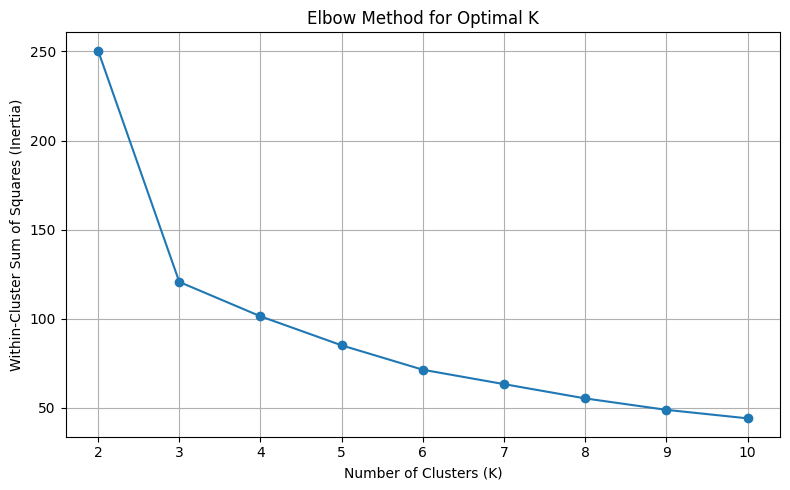

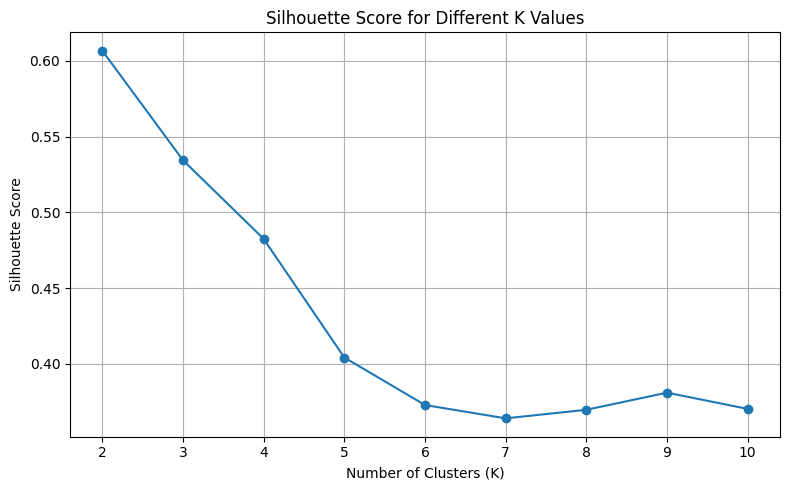


========== OPTIMAL NUMBER OF CLUSTERS ==========
Best K based on Silhouette Score: 2

========== K-MEANS RESULTS ==========
K-Means Silhouette Score: 0.6067

K-Means Cluster Counts:
KMeans_Cluster
0    190
1     60
Name: count, dtype: int64

========== K-MEANS CLUSTER CENTERS ==========
         Purchase_Frequency  Total_Spending  Browsing_Sessions
Cluster                                                       
0                      2.95          719.92               9.06
1                      6.23         1843.41              18.63


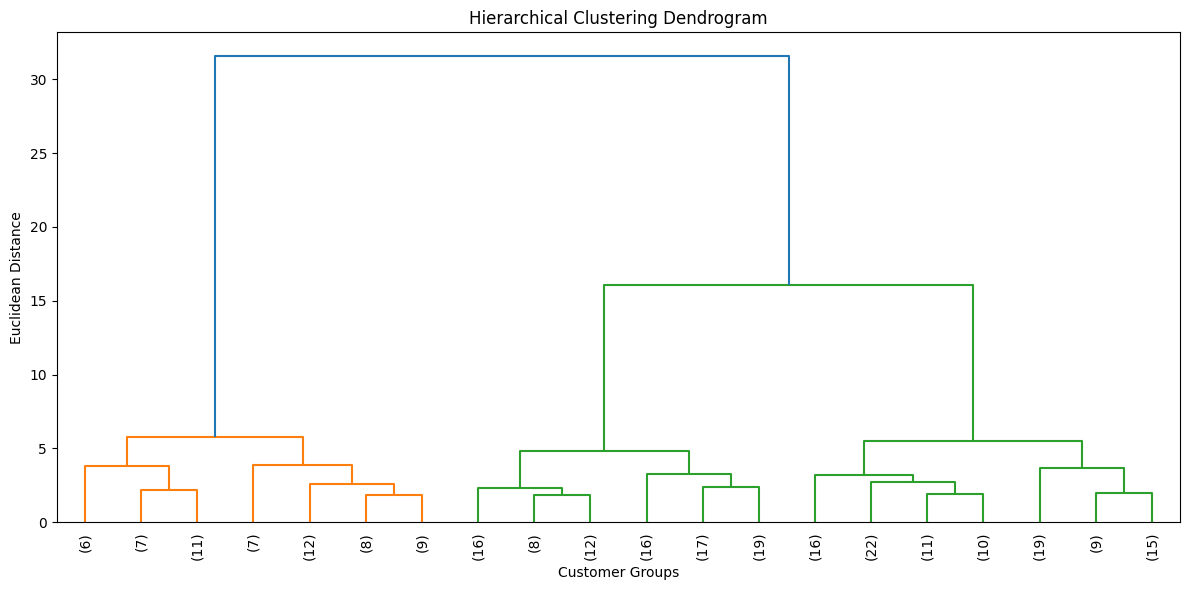


========== HIERARCHICAL RESULTS ==========
Hierarchical Silhouette Score: 0.6067

Hierarchical Cluster Counts:
Hierarchical_Cluster
0    190
1     60
Name: count, dtype: int64

========== CLUSTERING COMPARISON ==========
      Method  Number_of_Clusters  Silhouette_Score
     K-Means                   2            0.6067
Hierarchical                   2            0.6067

========== K-MEANS CUSTOMER PROFILES ==========
                Purchase_Frequency  Total_Spending  Browsing_Sessions  \
KMeans_Cluster                                                          
0                             2.95          718.00               9.06   
1                             6.29         1843.41              18.63   

                Customer_Count  
KMeans_Cluster                  
0                          190  
1                           60  

========== HIERARCHICAL CUSTOMER PROFILES ==========
                      Purchase_Frequency  Total_Spending  Browsing_Sessions  \
Hierarchical_Clust

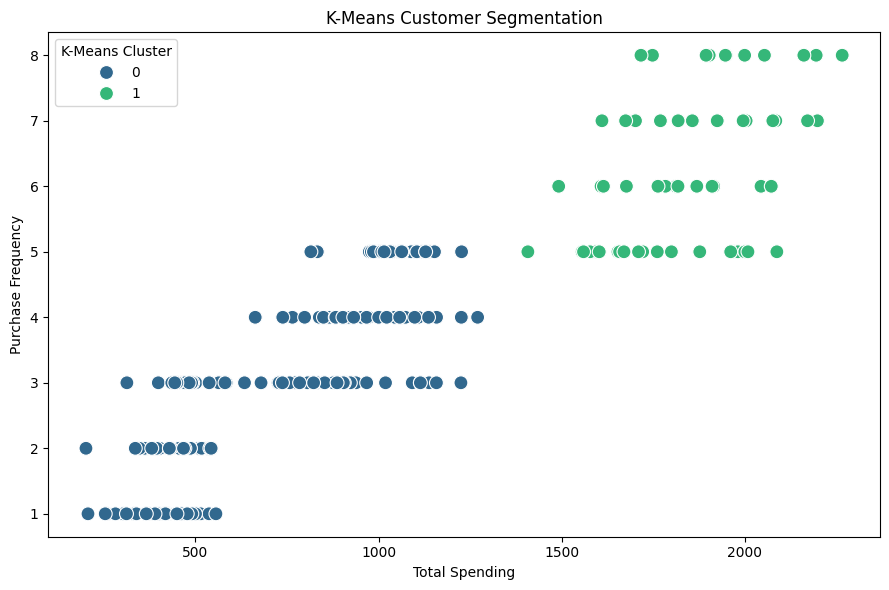

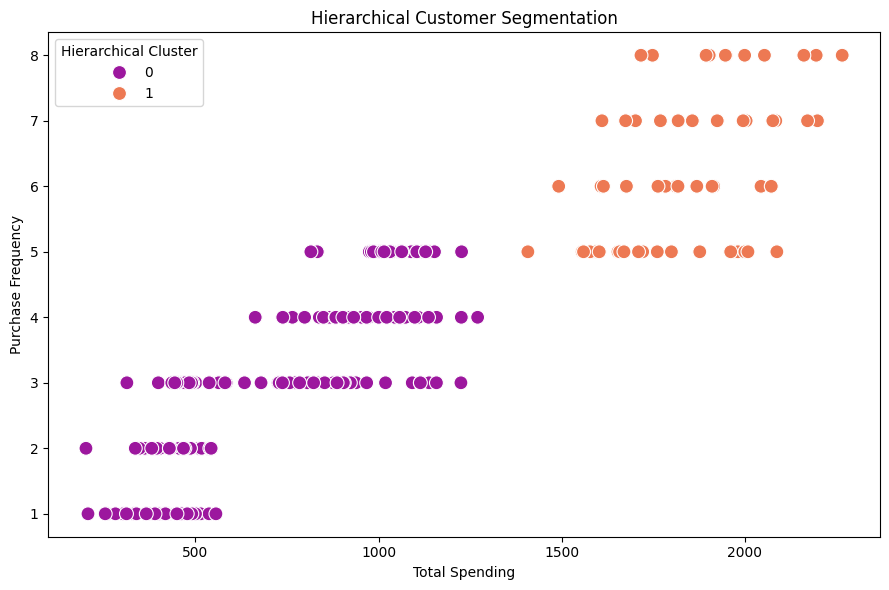

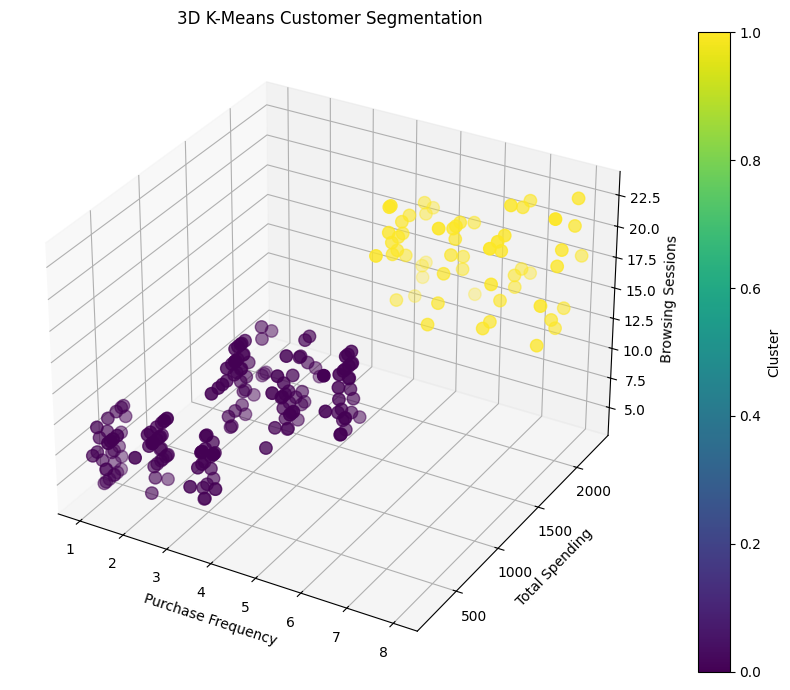


========== K-MEANS vs HIERARCHICAL ==========
Hierarchical_Cluster    0   1
KMeans_Cluster               
0                     190   0
1                       0  60

CLUSTERING ANALYSIS COMPLETED SUCCESSFULLY
Total Customers: 250
Optimal Number of Clusters: 2
K-Means Silhouette Score: 0.6067
Hierarchical Silhouette Score: 0.6067

Output files:
1. customer_clustered_results.csv
2. clustering_comparison.csv
3. kmeans_customer_profiles.csv
4. hierarchical_customer_profiles.csv


In [2]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

from google.colab import files

uploaded = files.upload()


df = pd.read_csv("online_shoppers_250 (1).csv")

print("\n========== DATASET ==========")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())



print("\n========== MISSING VALUES BEFORE HANDLING ==========")

missing_values = df.isnull().sum()

print(missing_values)

print(
    "\nTotal Missing Values:",
    df.isnull().sum().sum()
)


features = [
    "Purchase_Frequency",
    "Total_Spending",
    "Browsing_Sessions"
]

X = df[features].copy()

print("\n========== SELECTED FEATURES ==========")
print(X.head())




print("\n========== HANDLING MISSING VALUES ==========")


for column in features:

    median_value = X[column].median()

    X[column] = X[column].fillna(median_value)

    print(
        f"{column}: Missing values replaced with median = "
        f"{median_value:.2f}"
    )




print("\n========== MISSING VALUES AFTER HANDLING ==========")

print(X.isnull().sum())

print(
    "\nTotal Missing Values After Handling:",
    X.isnull().sum().sum()
)




scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=features
)

print("\n========== STANDARDIZED DATA ==========")

print(X_scaled_df.head())



inertia = []

K_range = range(2, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)


plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal K")

plt.xlabel("Number of Clusters (K)")

plt.ylabel("Within-Cluster Sum of Squares (Inertia)")

plt.grid(True)

plt.tight_layout()

plt.show()




silhouette_scores = []

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)


plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    silhouette_scores,
    marker="o"
)

plt.title(
    "Silhouette Score for Different K Values"
)

plt.xlabel(
    "Number of Clusters (K)"
)

plt.ylabel(
    "Silhouette Score"
)

plt.grid(True)

plt.tight_layout()

plt.show()




best_k = K_range[
    np.argmax(silhouette_scores)
]

print("\n========== OPTIMAL NUMBER OF CLUSTERS ==========")

print(
    "Best K based on Silhouette Score:",
    best_k
)



kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(
    X_scaled
)

df["KMeans_Cluster"] = kmeans_labels



kmeans_silhouette = silhouette_score(
    X_scaled,
    kmeans_labels
)

print("\n========== K-MEANS RESULTS ==========")

print(
    "K-Means Silhouette Score:",
    round(kmeans_silhouette, 4)
)

print("\nK-Means Cluster Counts:")

print(
    df["KMeans_Cluster"]
    .value_counts()
    .sort_index()
)



centers_scaled = kmeans.cluster_centers_

centers_original = scaler.inverse_transform(
    centers_scaled
)

centers_df = pd.DataFrame(
    centers_original,
    columns=features
)

centers_df.index.name = "Cluster"

print(
    "\n========== K-MEANS CLUSTER CENTERS =========="
)

print(
    centers_df.round(2)
)



linked = linkage(
    X_scaled,
    method="ward"
)

plt.figure(figsize=(12, 6))

dendrogram(
    linked,
    truncate_mode="lastp",
    p=20,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.title(
    "Hierarchical Clustering Dendrogram"
)

plt.xlabel(
    "Customer Groups"
)

plt.ylabel(
    "Euclidean Distance"
)

plt.tight_layout()

plt.show()




hierarchical = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(
    X_scaled
)

df["Hierarchical_Cluster"] = hierarchical_labels




hierarchical_silhouette = silhouette_score(
    X_scaled,
    hierarchical_labels
)

print(
    "\n========== HIERARCHICAL RESULTS =========="
)

print(
    "Hierarchical Silhouette Score:",
    round(hierarchical_silhouette, 4)
)

print(
    "\nHierarchical Cluster Counts:"
)

print(
    df["Hierarchical_Cluster"]
    .value_counts()
    .sort_index()
)




comparison = pd.DataFrame({

    "Method": [
        "K-Means",
        "Hierarchical"
    ],

    "Number_of_Clusters": [
        len(np.unique(kmeans_labels)),
        len(np.unique(hierarchical_labels))
    ],

    "Silhouette_Score": [
        kmeans_silhouette,
        hierarchical_silhouette
    ]
})


print(
    "\n========== CLUSTERING COMPARISON =========="
)

print(
    comparison.round(4).to_string(index=False)
)



kmeans_profile = (
    df
    .groupby("KMeans_Cluster")[features]
    .mean()
    .round(2)
)

kmeans_profile["Customer_Count"] = (
    df["KMeans_Cluster"]
    .value_counts()
)

kmeans_profile = kmeans_profile.sort_index()

print(
    "\n========== K-MEANS CUSTOMER PROFILES =========="
)

print(
    kmeans_profile
)



hierarchical_profile = (
    df
    .groupby("Hierarchical_Cluster")[features]
    .mean()
    .round(2)
)

hierarchical_profile["Customer_Count"] = (
    df["Hierarchical_Cluster"]
    .value_counts()
)

hierarchical_profile = hierarchical_profile.sort_index()

print(
    "\n========== HIERARCHICAL CUSTOMER PROFILES =========="
)

print(
    hierarchical_profile
)




plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Total_Spending",
    y="Purchase_Frequency",
    hue="KMeans_Cluster",
    palette="viridis",
    s=100
)

plt.title(
    "K-Means Customer Segmentation"
)

plt.xlabel(
    "Total Spending"
)

plt.ylabel(
    "Purchase Frequency"
)

plt.legend(
    title="K-Means Cluster"
)

plt.tight_layout()

plt.show()



plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Total_Spending",
    y="Purchase_Frequency",
    hue="Hierarchical_Cluster",
    palette="plasma",
    s=100
)

plt.title(
    "Hierarchical Customer Segmentation"
)

plt.xlabel(
    "Total Spending"
)

plt.ylabel(
    "Purchase Frequency"
)

plt.legend(
    title="Hierarchical Cluster"
)

plt.tight_layout()

plt.show()




fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(
    111,
    projection="3d"
)

scatter = ax.scatter(
    df["Purchase_Frequency"],
    df["Total_Spending"],
    df["Browsing_Sessions"],
    c=df["KMeans_Cluster"],
    cmap="viridis",
    s=80
)

ax.set_title(
    "3D K-Means Customer Segmentation"
)

ax.set_xlabel(
    "Purchase Frequency"
)

ax.set_ylabel(
    "Total Spending"
)

ax.set_zlabel(
    "Browsing Sessions"
)

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.tight_layout()

plt.show()



cluster_cross_tab = pd.crosstab(
    df["KMeans_Cluster"],
    df["Hierarchical_Cluster"]
)

print(
    "\n========== K-MEANS vs HIERARCHICAL =========="
)

print(
    cluster_cross_tab
)




df.to_csv(
    "customer_clustered_results.csv",
    index=False
)

comparison.to_csv(
    "clustering_comparison.csv",
    index=False
)

kmeans_profile.to_csv(
    "kmeans_customer_profiles.csv"
)

hierarchical_profile.to_csv(
    "hierarchical_customer_profiles.csv"
)




print(
    "\n================================================"
)

print(
    "CLUSTERING ANALYSIS COMPLETED SUCCESSFULLY"
)

print(
    "================================================"
)

print(
    f"Total Customers: {len(df)}"
)

print(
    f"Optimal Number of Clusters: {best_k}"
)

print(
    f"K-Means Silhouette Score: "
    f"{kmeans_silhouette:.4f}"
)

print(
    f"Hierarchical Silhouette Score: "
    f"{hierarchical_silhouette:.4f}"
)

print(
    "\nOutput files:"
)

print(
    "1. customer_clustered_results.csv"
)

print(
    "2. clustering_comparison.csv"
)

print(
    "3. kmeans_customer_profiles.csv"
)

print(
    "4. hierarchical_customer_profiles.csv"
)